# Transformation Matrices and Orthogonal Basis Sets

## 📚 Learning Objectives

By completing this notebook, you will:
- Write code to apply transformation matrices
- Compute orthogonal basis sets computationally
- Understand basis transformations in linear algebra
- Apply transformations to ML problems

## 🔗 Prerequisites

- ✅ Understanding of matrix operations
- ✅ Understanding of vectors and matrices
- ✅ Python and NumPy knowledge

---

This notebook covers practical activities from **Course 03, Unit 1**:
- Writing code to apply transformation matrices and compute orthogonal basis sets

---

## Introduction

**Transformation matrices** represent linear transformations in space, and **orthogonal basis sets** are fundamental for efficient representations in machine learning.

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import qr, orth

print("✅ Libraries imported!")
print("\nTransformation Matrices and Orthogonal Basis Sets")
print("=" * 60)


✅ Libraries imported!

Transformation Matrices and Orthogonal Basis Sets


## Part 1: Applying Transformation Matrices


Part 1: Applying Transformation Matrices

Original points:
[[1 0]
 [0 1]
 [1 1]
 [2 1]]

Rotated 90° counterclockwise:
[[ 0  1]
 [-1  0]
 [-1  1]
 [-1  2]]

Scaled (x*2, y*3):
[[2 0]
 [0 3]
 [2 3]
 [4 3]]

Sheared:
[[1.  0. ]
 [0.5 1. ]
 [1.5 1. ]
 [2.5 1. ]]


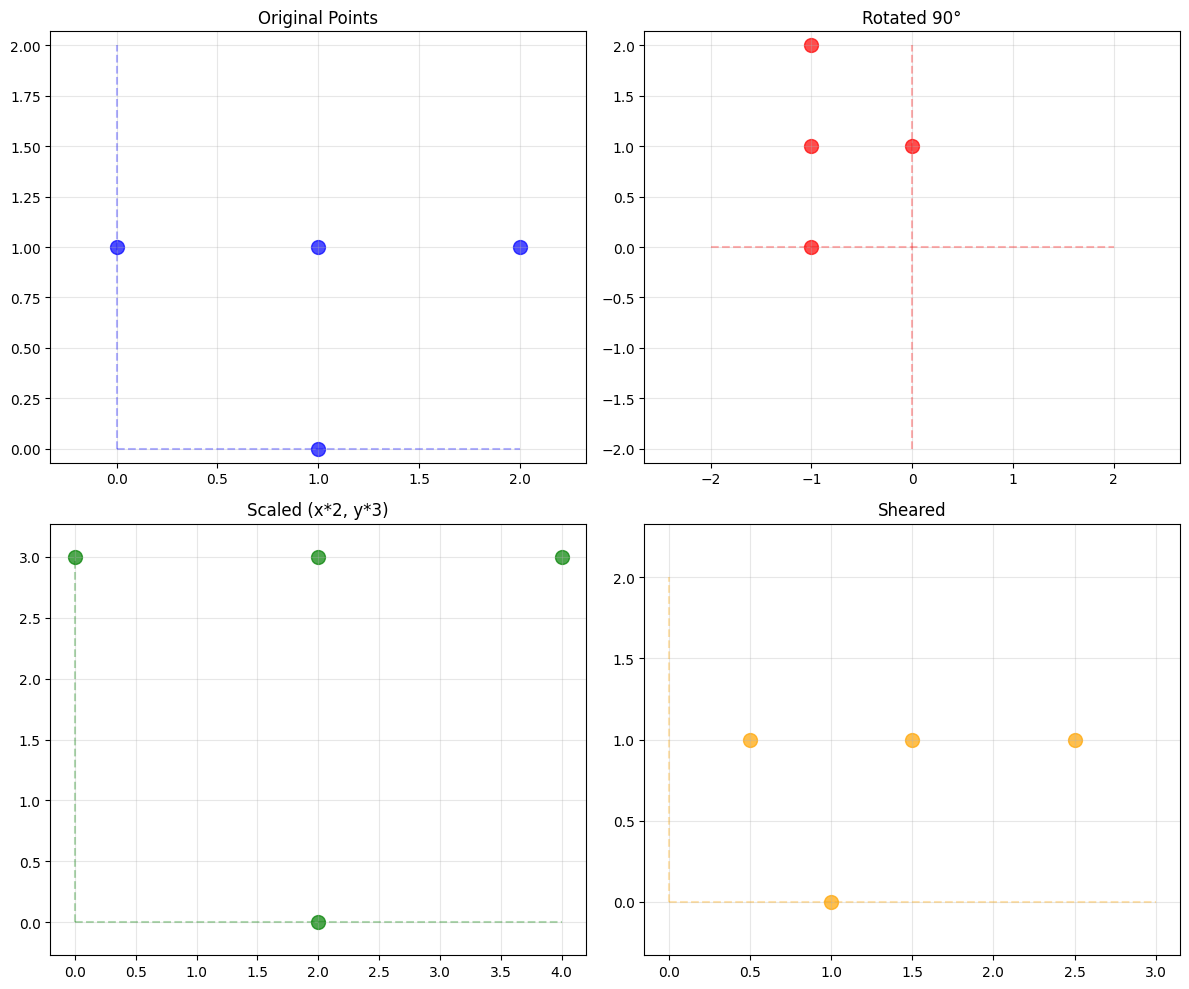


✅ Transformation matrices applied and visualized!


In [2]:
print("=" * 60)
print("Part 1: Applying Transformation Matrices")
print("=" * 60)

# Transformation matrices represent linear transformations
# Examples: rotation, scaling, reflection, shearing

def apply_transformation(points, transformation_matrix):
    """Apply transformation matrix to points"""
    return (transformation_matrix @ points.T).T

# Example: 2D points
points = np.array([[1, 0],
 [0, 1],
 [1, 1],
 [2, 1]])

print("\nOriginal points:")
print(points)

# Rotation matrix (90 degrees counterclockwise)
rotation_90 = np.array([[0, -1],
 [1, 0]])

rotated_points = apply_transformation(points, rotation_90)
print("\nRotated 90° counterclockwise:")
print(rotated_points)

# Scaling matrix
scaling = np.array([[2, 0],
 [0, 3]])

scaled_points = apply_transformation(points, scaling)
print("\nScaled (x*2, y*3):")
print(scaled_points)

# Shear transformation
shear = np.array([[1, 0.5],
 [0, 1]])

sheared_points = apply_transformation(points, shear)
print("\nSheared:")
print(sheared_points)

# Visualize transformations
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# Original
axes[0, 0].scatter(points[:, 0], points[:, 1], c='blue', s=100, alpha=0.7)
axes[0, 0].plot([0, 0], [0, 2], 'b--', alpha=0.3)
axes[0, 0].plot([0, 2], [0, 0], 'b--', alpha=0.3)
axes[0, 0].set_title('Original Points')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xlim(-2, 3)
axes[0, 0].set_ylim(-2, 3)
axes[0, 0].axis('equal')

# Rotated
axes[0, 1].scatter(rotated_points[:, 0], rotated_points[:, 1], c='red', s=100, alpha=0.7)
axes[0, 1].plot([0, 0], [-2, 2], 'r--', alpha=0.3)
axes[0, 1].plot([-2, 2], [0, 0], 'r--', alpha=0.3)
axes[0, 1].set_title('Rotated 90°')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xlim(-2, 3)
axes[0, 1].set_ylim(-2, 3)
axes[0, 1].axis('equal')

# Scaled
axes[1, 0].scatter(scaled_points[:, 0], scaled_points[:, 1], c='green', s=100, alpha=0.7)
axes[1, 0].plot([0, 0], [0, 3], 'g--', alpha=0.3)
axes[1, 0].plot([0, 4], [0, 0], 'g--', alpha=0.3)
axes[1, 0].set_title('Scaled (x*2, y*3)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xlim(-1, 5)
axes[1, 0].set_ylim(-1, 4)
axes[1, 0].axis('equal')

# Sheared
axes[1, 1].scatter(sheared_points[:, 0], sheared_points[:, 1], c='orange', s=100, alpha=0.7)
axes[1, 1].plot([0, 0], [0, 2], 'orange', linestyle='--', alpha=0.3)
axes[1, 1].plot([0, 3], [0, 0], 'orange', linestyle='--', alpha=0.3)
axes[1, 1].set_title('Sheared')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim(-1, 4)
axes[1, 1].set_ylim(-1, 2)
axes[1, 1].axis('equal')

plt.tight_layout()
plt.show()

print("\n✅ Transformation matrices applied and visualized!")


## Part 2: Computing Orthogonal Basis Sets


In [3]:
print("\n" + "=" * 60)
print("Part 2: Computing Orthogonal Basis Sets")
print("=" * 60)
def gram_schmidt(vectors):
    """
    Compute orthogonal basis using Gram-Schmidt process.
    vectors: matrix where each row is a vector
    Returns: orthogonal basis
    """
    n = len(vectors)
    orthogonal = np.zeros_like(vectors, dtype=float)
    
    for i in range(n):
        orthogonal[i] = vectors[i].copy()
        # Subtract projections onto previous vectors
        for j in range(i):
            proj = np.dot(vectors[i], orthogonal[j]) / np.dot(orthogonal[j], orthogonal[j])
            orthogonal[i] -= proj * orthogonal[j]
        
        # Normalize
        norm = np.linalg.norm(orthogonal[i])
        if norm > 1e-10:
            orthogonal[i] = orthogonal[i] / norm
    
    return orthogonal

# Example: Create orthogonal basis
A = np.array([[1, 1, 0],
 [1, 0, 1],
 [0, 1, 1]])
print("\nOriginal vectors (rows of A):")
print(A)
# Using Gram-Schmidt
orthogonal_manual = gram_schmidt(A)
print("\nOrthogonal basis (Gram-Schmidt):")
print(orthogonal_manual)
# Verify orthogonality
print("\nVerification (should be identity for orthogonal basis):")
print(orthogonal_manual @ orthogonal_manual.T)
# Using NumPy QR decomposition (more stable)
Q, R = np.linalg.qr(A.T)
Q = Q.T
print("\nOrthogonal basis (QR decomposition):")
print(Q)
# Verify orthogonality
print("\nVerification (should be identity):")
print(Q @ Q.T)
print("\n✅ Orthogonal basis computed using Gram-Schmidt and QR!")



Part 2: Computing Orthogonal Basis Sets

Original vectors (rows of A):
[[1 1 0]
 [1 0 1]
 [0 1 1]]

Orthogonal basis (Gram-Schmidt):
[[ 0.70710678  0.70710678  0.        ]
 [ 0.40824829 -0.40824829  0.81649658]
 [-0.57735027  0.57735027  0.57735027]]

Verification (should be identity for orthogonal basis):
[[1.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 1.00000000e+00 1.11022302e-16]
 [0.00000000e+00 1.11022302e-16 1.00000000e+00]]

Orthogonal basis (QR decomposition):
[[-0.70710678 -0.70710678 -0.        ]
 [ 0.40824829 -0.40824829  0.81649658]
 [-0.57735027  0.57735027  0.57735027]]

Verification (should be identity):
[[ 1.00000000e+00  1.11022302e-16 -1.11022302e-16]
 [ 1.11022302e-16  1.00000000e+00 -1.03593182e-16]
 [-1.11022302e-16 -1.03593182e-16  1.00000000e+00]]

✅ Orthogonal basis computed using Gram-Schmidt and QR!


## Part 3: Application to ML Problems

> 🔭 **Forward-looking demo**: the cell below uses scikit-learn's `PCA`, which is taught fully in **Unit 4** (`01_pca_implementation.ipynb`). Here we only use it to show that the directions PCA finds form an **orthogonal basis** — exactly the property this lesson is about. Treat `PCA` as a black box for now.


In [4]:
print("\n" + "=" * 60)
print("Part 3: Application to ML Problems")
print("=" * 60)

# Example: PCA as orthogonal transformation
# PCA finds orthogonal basis that maximizes variance
print("\nPCA as Orthogonal Transformation:")
print("-" * 60)

from sklearn.decomposition import PCA

# Sample data
np.random.seed(42)
X = np.random.randn(100, 3)
X[:, 2] = X[:, 0] + 0.5 * X[:, 1] # Create correlation

print(f"Original data shape: {X.shape}")

# PCA finds orthogonal basis
pca = PCA(n_components=3)
X_transformed = pca.fit_transform(X)

# Principal components (orthogonal basis)
components = pca.components_
print(f"\nPrincipal components (orthogonal basis):")
print(components)

# Verify orthogonality
print("\nVerification - Components are orthogonal:")
print(components @ components.T)

# Variance explained
print(f"\nVariance explained by each component:")
print(pca.explained_variance_ratio_)

print("\n✅ PCA uses orthogonal transformation for dimensionality reduction!")



Part 3: Application to ML Problems

PCA as Orthogonal Transformation:
------------------------------------------------------------


Original data shape: (100, 3)

Principal components (orthogonal basis):
[[ 0.49986451  0.46352619  0.7316276 ]
 [-0.55289332  0.82099474 -0.14239595]
 [ 0.66666667  0.33333333 -0.66666667]]

Verification - Components are orthogonal:
[[ 1.00000000e+00 -5.55111512e-17  1.94289029e-16]
 [-5.55111512e-17  1.00000000e+00  5.29360328e-17]
 [ 1.94289029e-16  5.29360328e-17  1.00000000e+00]]

Variance explained by each component:
[6.39322674e-01 3.60677326e-01 9.67379302e-17]

✅ PCA uses orthogonal transformation for dimensionality reduction!


## Summary

### Key Concepts:
1. **Transformation Matrices**: Represent linear transformations (rotation, scaling, shear)
2. **Orthogonal Basis**: Set of orthogonal unit vectors
3. **Gram-Schmidt Process**: Algorithm to create orthogonal basis from arbitrary vectors
4. **QR Decomposition**: Matrix factorization into orthogonal and upper triangular matrices

### Best Practices:
- Use QR decomposition (more numerically stable) over Gram-Schmidt
- Verify orthogonality by checking Q @ Q.T = I
- Normalize vectors to create orthonormal basis

### Applications:
- PCA (principal component analysis)
- Dimensionality reduction
- Feature transformation
- Neural network weight initialization

**Reference:** Course 03, Unit 1: "Linear Algebra for Machine Learning" - Transformation matrices and orthogonal basis practical content
